In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# Set style
sns.set_theme(style="whitegrid")

# Define paths
base_path = [r'c:\Files\Degree\FYP\FYP_ver5\Results\30seeds_results']
datasets = ['Twitter','Twitter2','Reddit','RedditSNS']

# Function to find 10S model folders
def find_model_folders(base_path, datasets):
    model_folders = []
    for base_path in base_path:
        for dataset in datasets:
            dataset_path = os.path.join(base_path, dataset)
            if not os.path.exists(dataset_path):
                continue
                
            for folder in os.listdir(dataset_path):
                if folder.startswith('30S') and os.path.isdir(os.path.join(dataset_path, folder)):
                    # Check if history file exists
                    history_file = os.path.join(dataset_path, folder, f"{folder}_training_history.xlsx")
                    if os.path.exists(history_file):
                        model_folders.append({
                            'dataset': dataset,
                            'folder': folder,
                            'path': history_file,
                            'is_baseline': 'baseline' in folder.lower()
                        })
    return model_folders

models = find_model_folders(base_path, datasets)
print(f"Found {len(models)} models:")
for m in models:
    print(f"  - {m['dataset']}: {m['folder']}")

Found 8 models:
  - Twitter: 30ST_baseline_algo
  - Twitter: 30ST_tcn_model_mb_precompute_pool_sgd
  - Twitter2: 30ST2_baseline_algo
  - Twitter2: 30ST2_tcn_model_mb_precompute_pool_sgd
  - Reddit: 30SR_baseline_algo
  - Reddit: 30SR_tcn_model_mb_precompute_pool_sgd
  - RedditSNS: 30SRsns_baseline_algo
  - RedditSNS: 30SRsns_tcn_model_mb_precompute_pool_sgd


In [2]:
def process_model_history(model_info):
    file_path = model_info['path']
    is_baseline = model_info['is_baseline']
    
    try:
        sheets = pd.read_excel(file_path, sheet_name=None)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return None

    all_folds_data = []

    for sheet_name, df in sheets.items():
        # Normalize column names to lowercase for easier checking
        df.columns = [c.lower() for c in df.columns]
        
        # Map expected columns
        col_map = {
            'train_loss': 'loss',
            'val_loss': 'val_loss',
            'train_accuracy': 'accuracy',
            'val_accuracy': 'val_accuracy'
        }
        
        # Rename columns if they match our expected keys
        df = df.rename(columns=col_map)
        
        # Ensure required columns exist
        if 'loss' not in df.columns or 'val_loss' not in df.columns:
            # Try checking if 'loss' is just 'loss' (keras default)
            if 'loss' not in df.columns:
                 # print(f"Missing loss columns in {sheet_name}. Columns: {df.columns}")
                 continue
        
        # Reset index to ensure it's 0-based integers
        df = df.reset_index(drop=True)
            
        # Handle Early Stopping
        if not is_baseline:
            # Find the epoch with the minimum validation loss
            # We assume the model was restored to this state.
            # Any epochs after this were part of the 'patience' and should be discarded
            # as per the user's request to "not plot for the other curves".
            best_epoch_idx = df['val_loss'].idxmin()
            
            # Truncate the dataframe to keep history up to the best epoch
            # (Since we restore best weights, the subsequent epochs are discarded)
            df_subset = df.iloc[:best_epoch_idx + 1].copy()
        else:
            # Baseline: Keep all epochs
            df_subset = df.copy()
            
        # Add Epoch column (1-based) if not present, or ensure it's correct
        if 'epoch' not in df_subset.columns:
            df_subset['Epoch'] = range(1, len(df_subset) + 1)
        else:
            # Capitalize Epoch for consistency
            df_subset = df_subset.rename(columns={'epoch': 'Epoch'})
            
        df_subset['Fold_Sheet'] = sheet_name
        
        all_folds_data.append(df_subset)
        
    if not all_folds_data:
        return None
        
    return pd.concat(all_folds_data, ignore_index=True)

Processing 30ST_baseline_algo...
  - Found 30 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\30seeds_results\Twitter\30ST_baseline_algo\30ST_baseline_algo_learning_curves_detailed.png


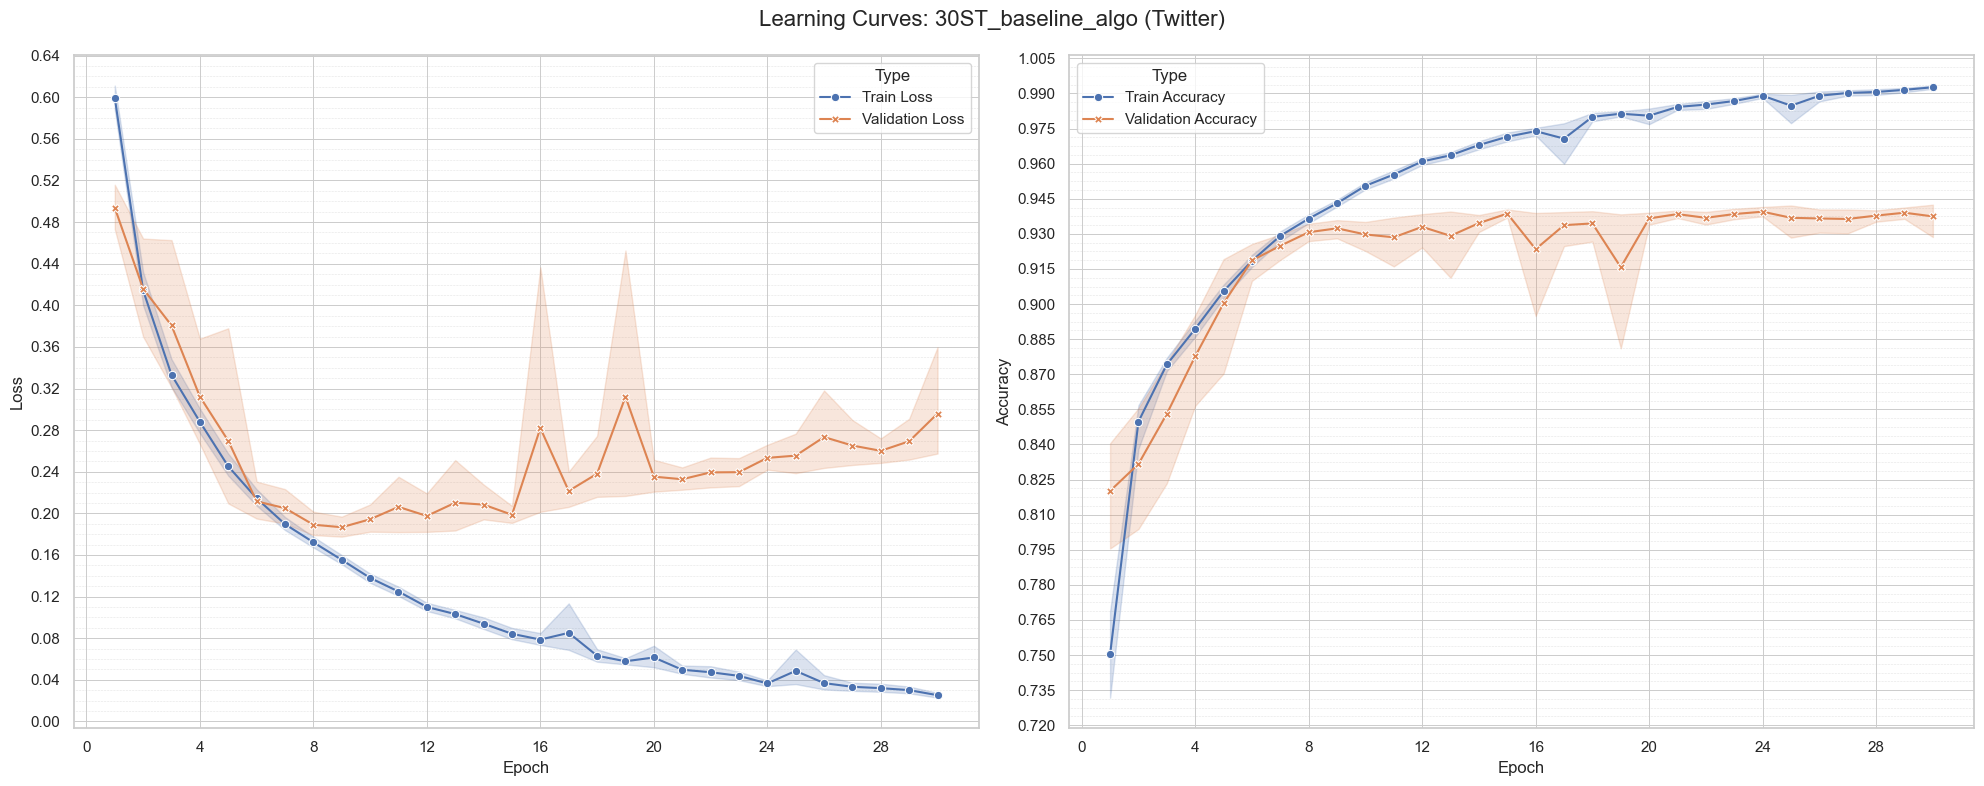

Processing 30ST_tcn_model_mb_precompute_pool_sgd...
  - Found 30 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\30seeds_results\Twitter\30ST_tcn_model_mb_precompute_pool_sgd\30ST_tcn_model_mb_precompute_pool_sgd_learning_curves_detailed.png


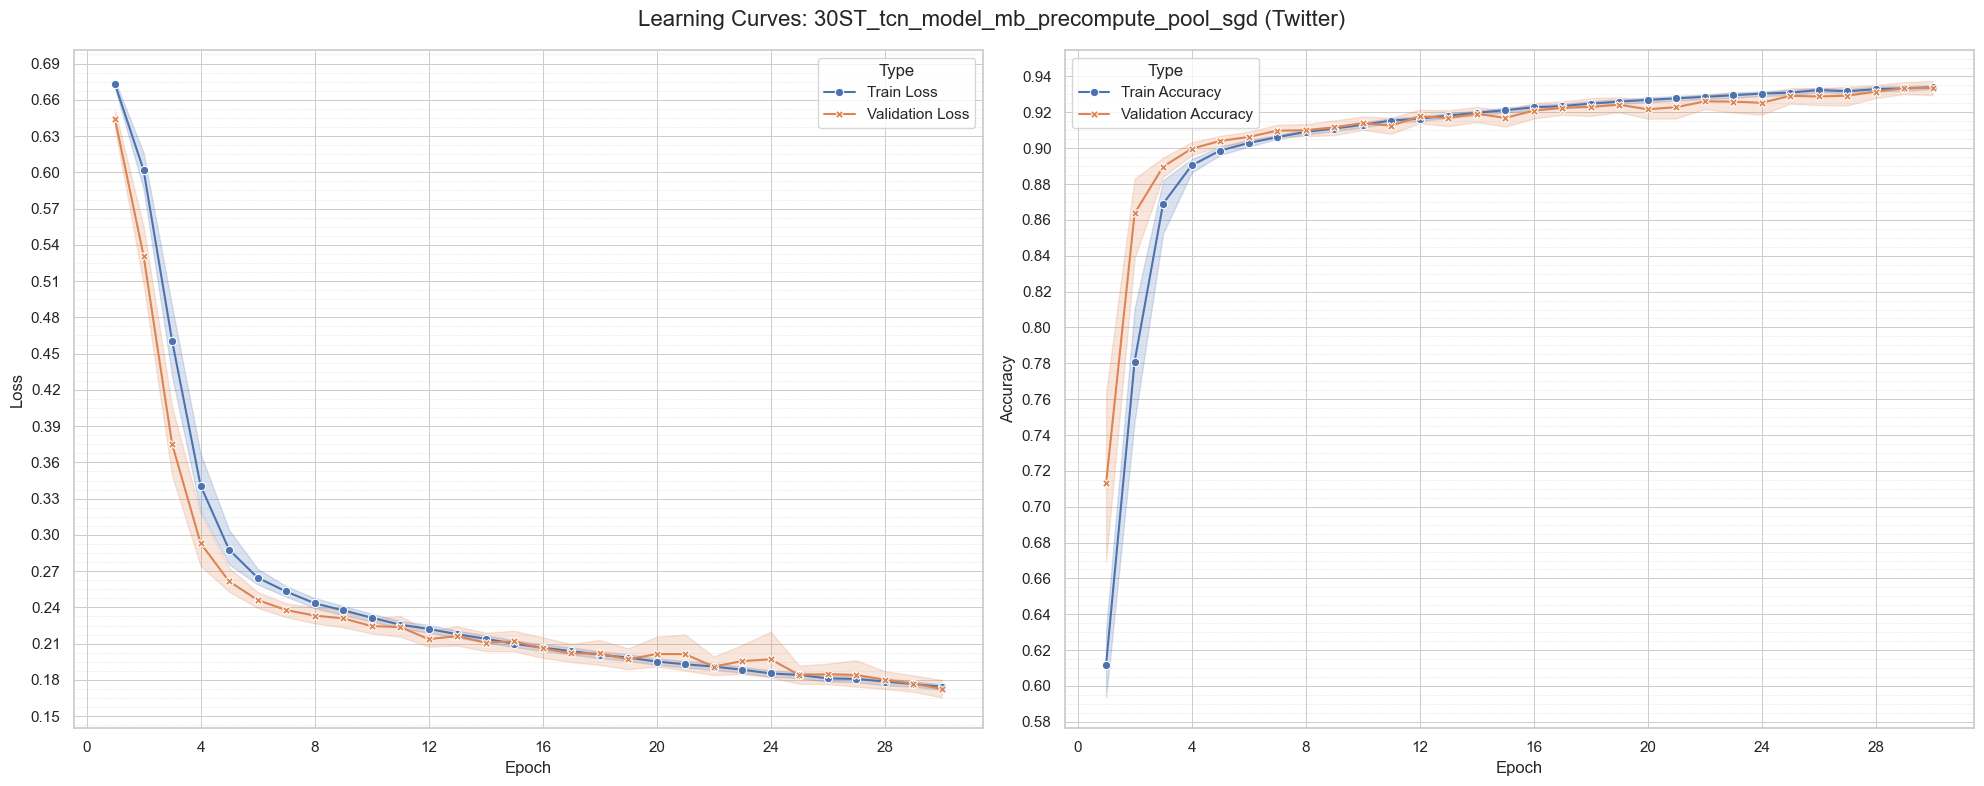

Processing 30ST2_baseline_algo...
  - Found 30 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\30seeds_results\Twitter2\30ST2_baseline_algo\30ST2_baseline_algo_learning_curves_detailed.png


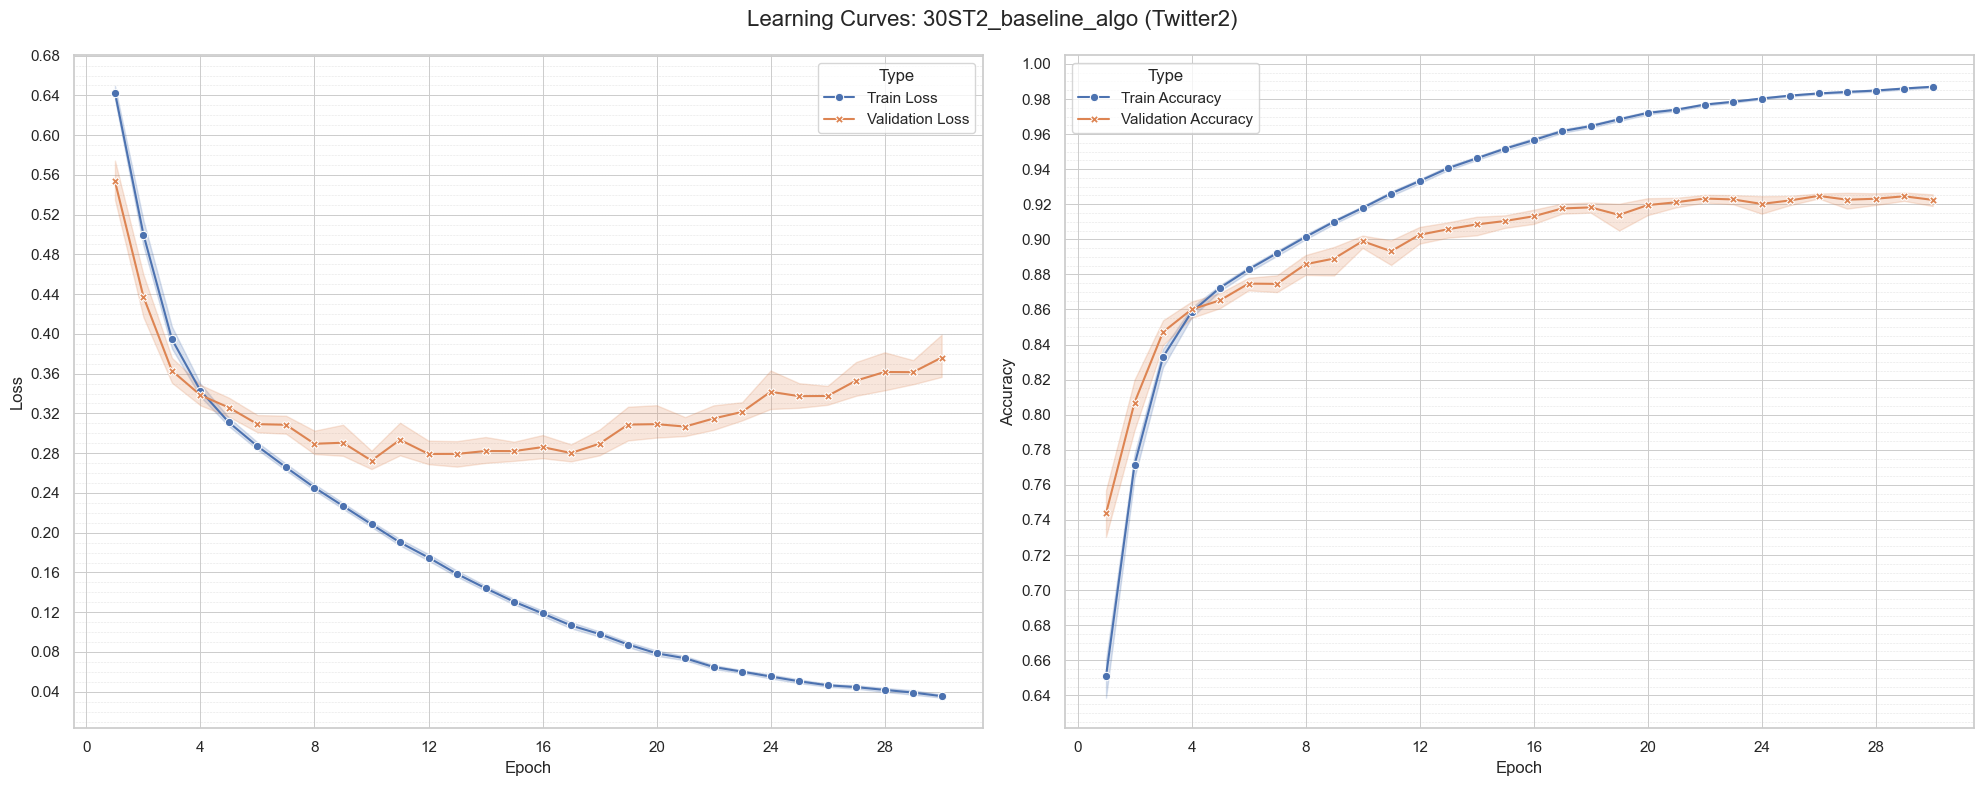

Processing 30ST2_tcn_model_mb_precompute_pool_sgd...
  - Found 30 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\30seeds_results\Twitter2\30ST2_tcn_model_mb_precompute_pool_sgd\30ST2_tcn_model_mb_precompute_pool_sgd_learning_curves_detailed.png


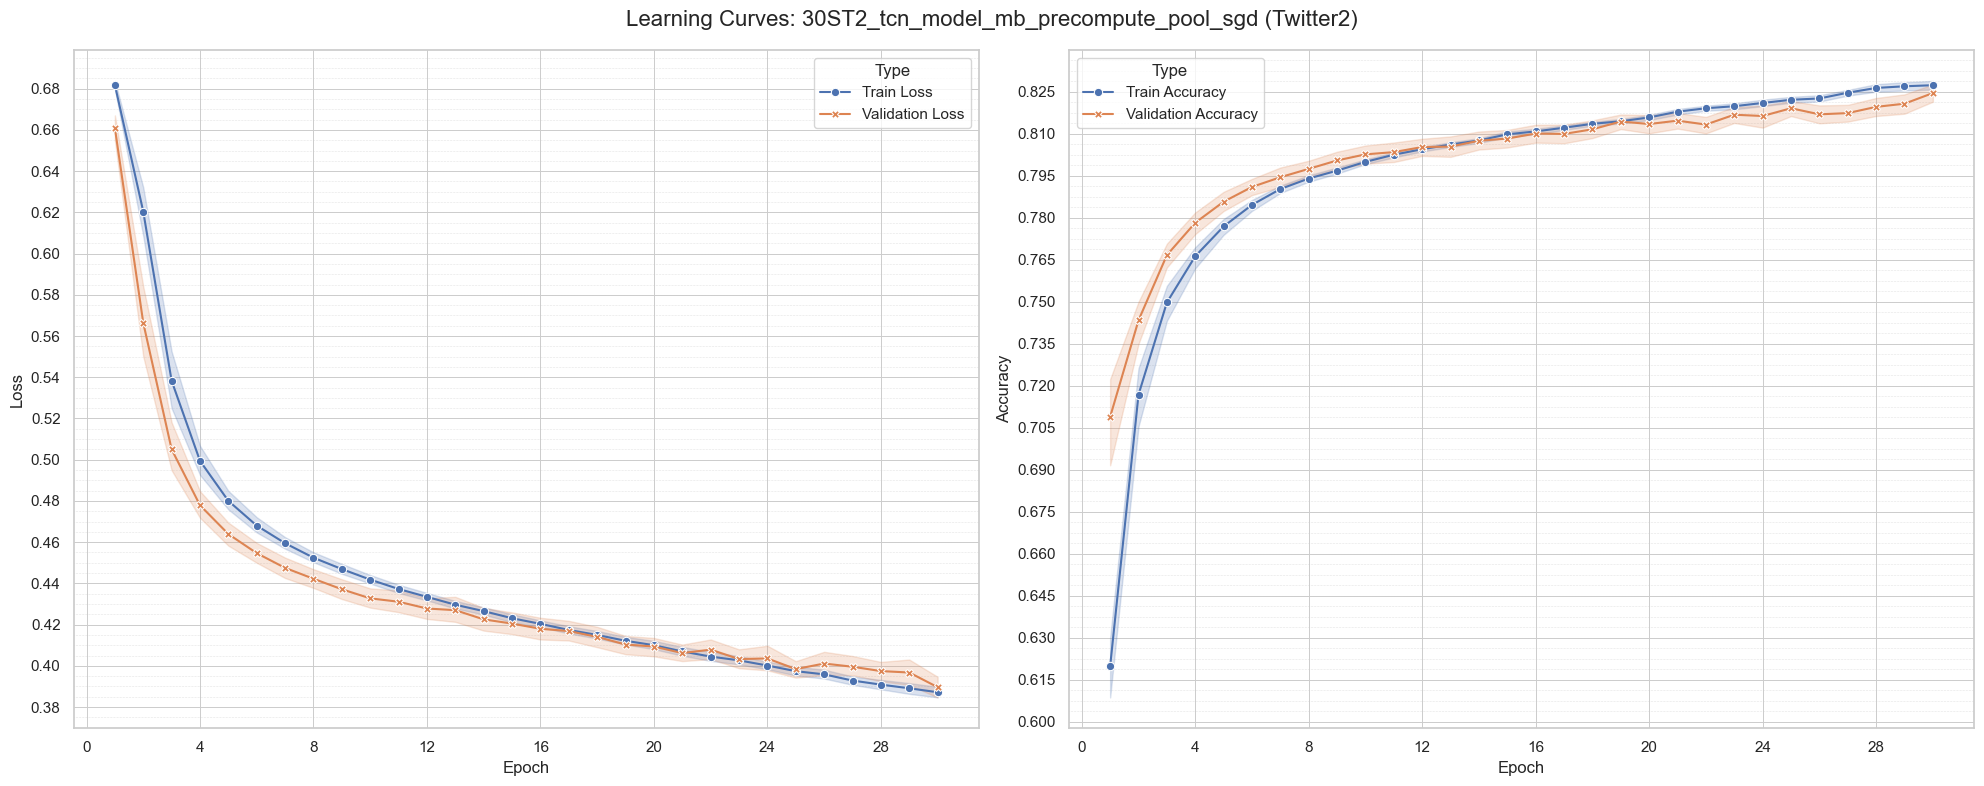

Processing 30SR_baseline_algo...
  - Found 30 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\30seeds_results\Reddit\30SR_baseline_algo\30SR_baseline_algo_learning_curves_detailed.png


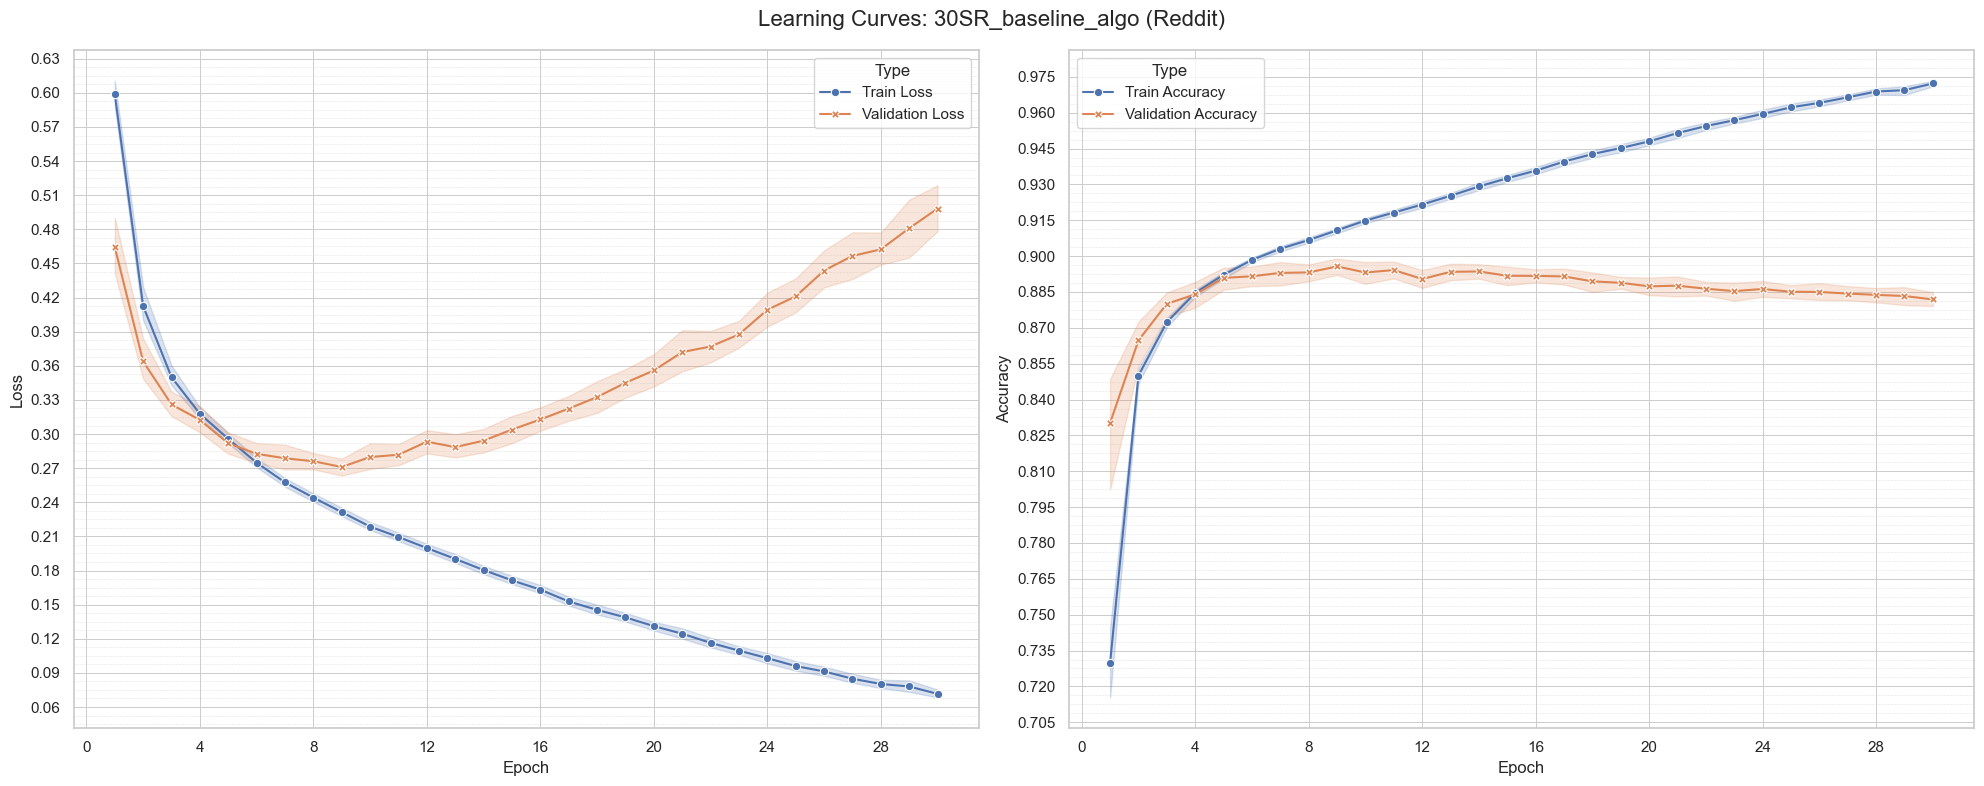

Processing 30SR_tcn_model_mb_precompute_pool_sgd...
  - Found 30 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\30seeds_results\Reddit\30SR_tcn_model_mb_precompute_pool_sgd\30SR_tcn_model_mb_precompute_pool_sgd_learning_curves_detailed.png


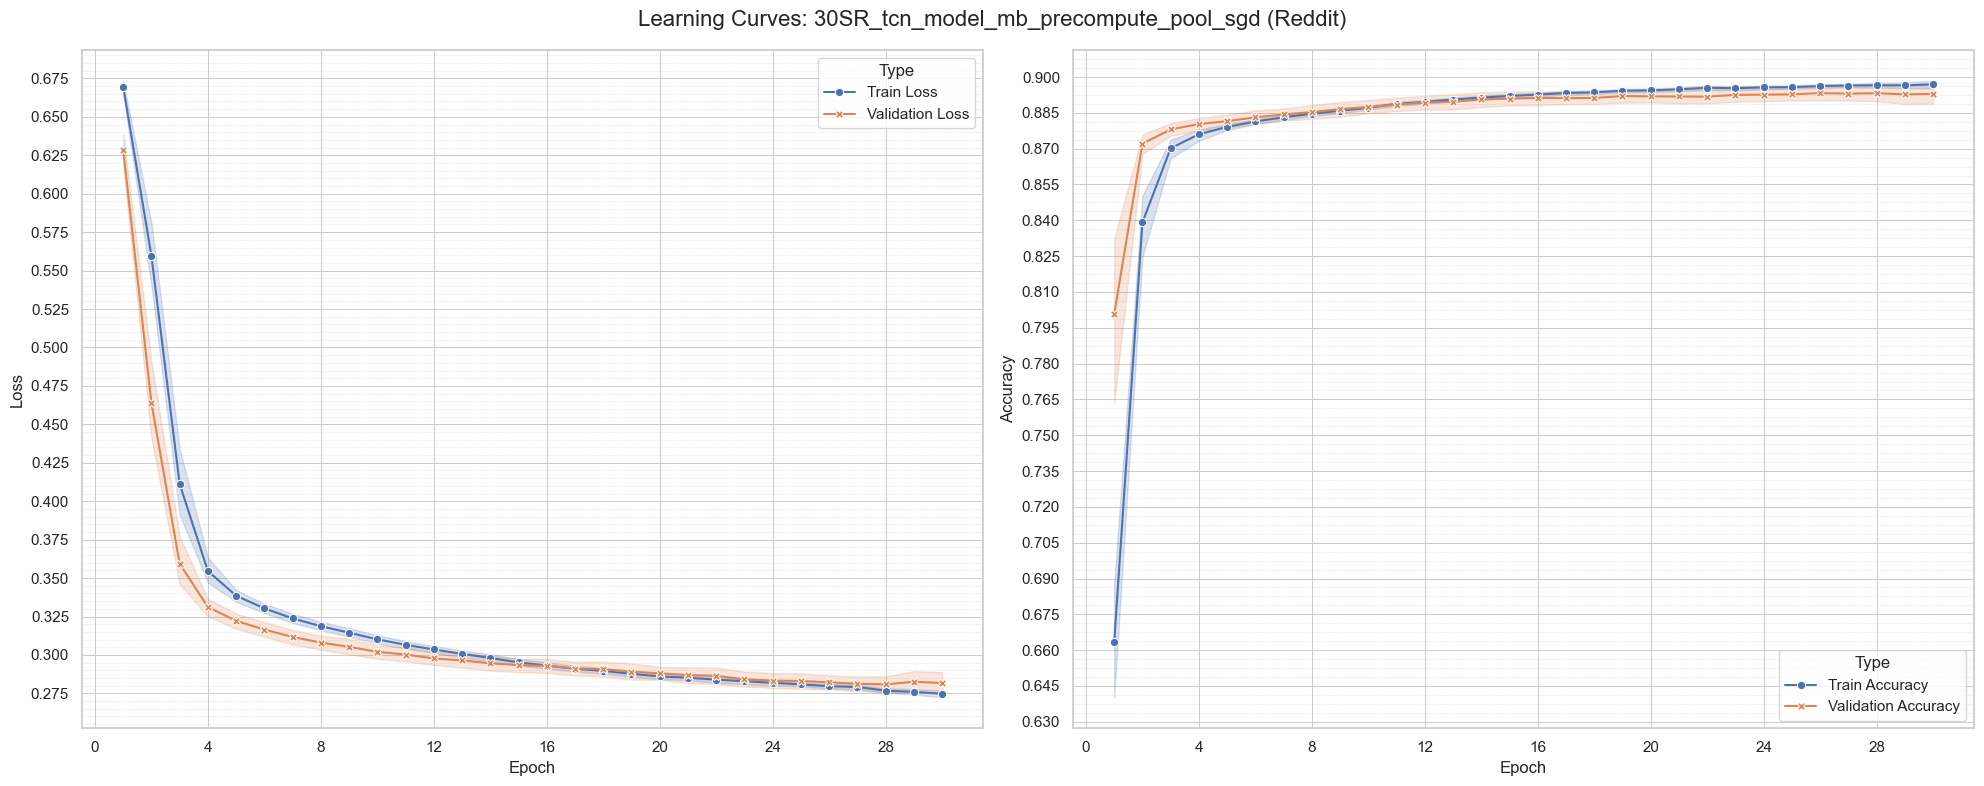

Processing 30SRsns_baseline_algo...
  - Found 30 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\30seeds_results\RedditSNS\30SRsns_baseline_algo\30SRsns_baseline_algo_learning_curves_detailed.png


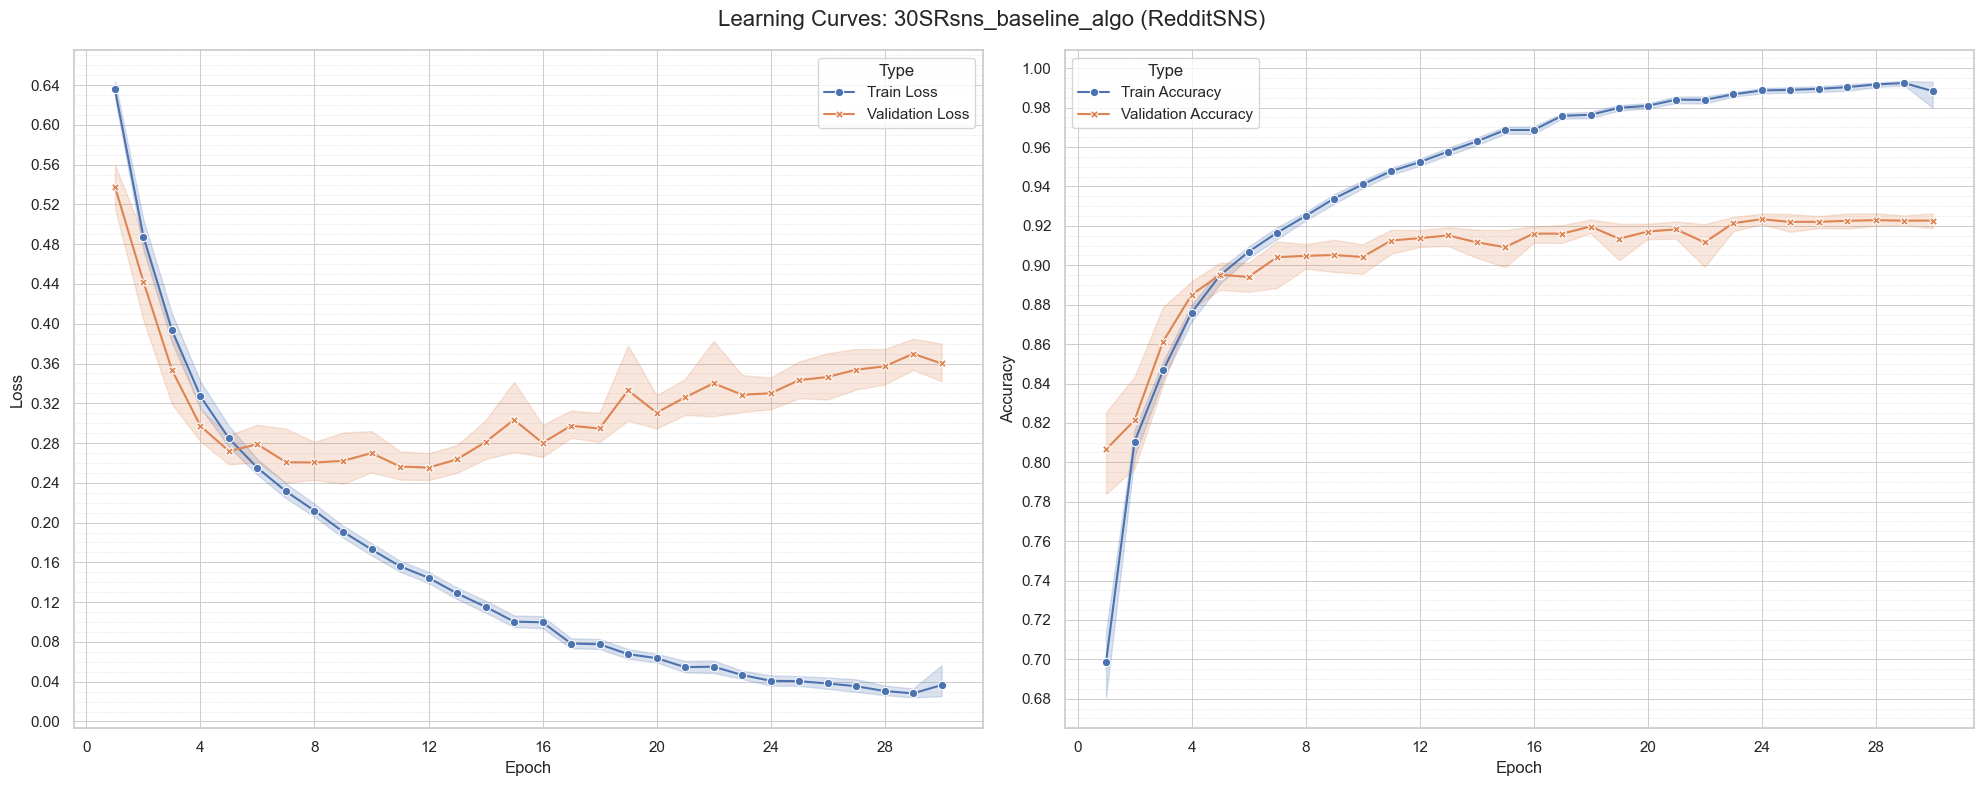

Processing 30SRsns_tcn_model_mb_precompute_pool_sgd...
  - Found 30 runs/folds.
Saved to c:\Files\Degree\FYP\FYP_ver5\Results\30seeds_results\RedditSNS\30SRsns_tcn_model_mb_precompute_pool_sgd\30SRsns_tcn_model_mb_precompute_pool_sgd_learning_curves_detailed.png


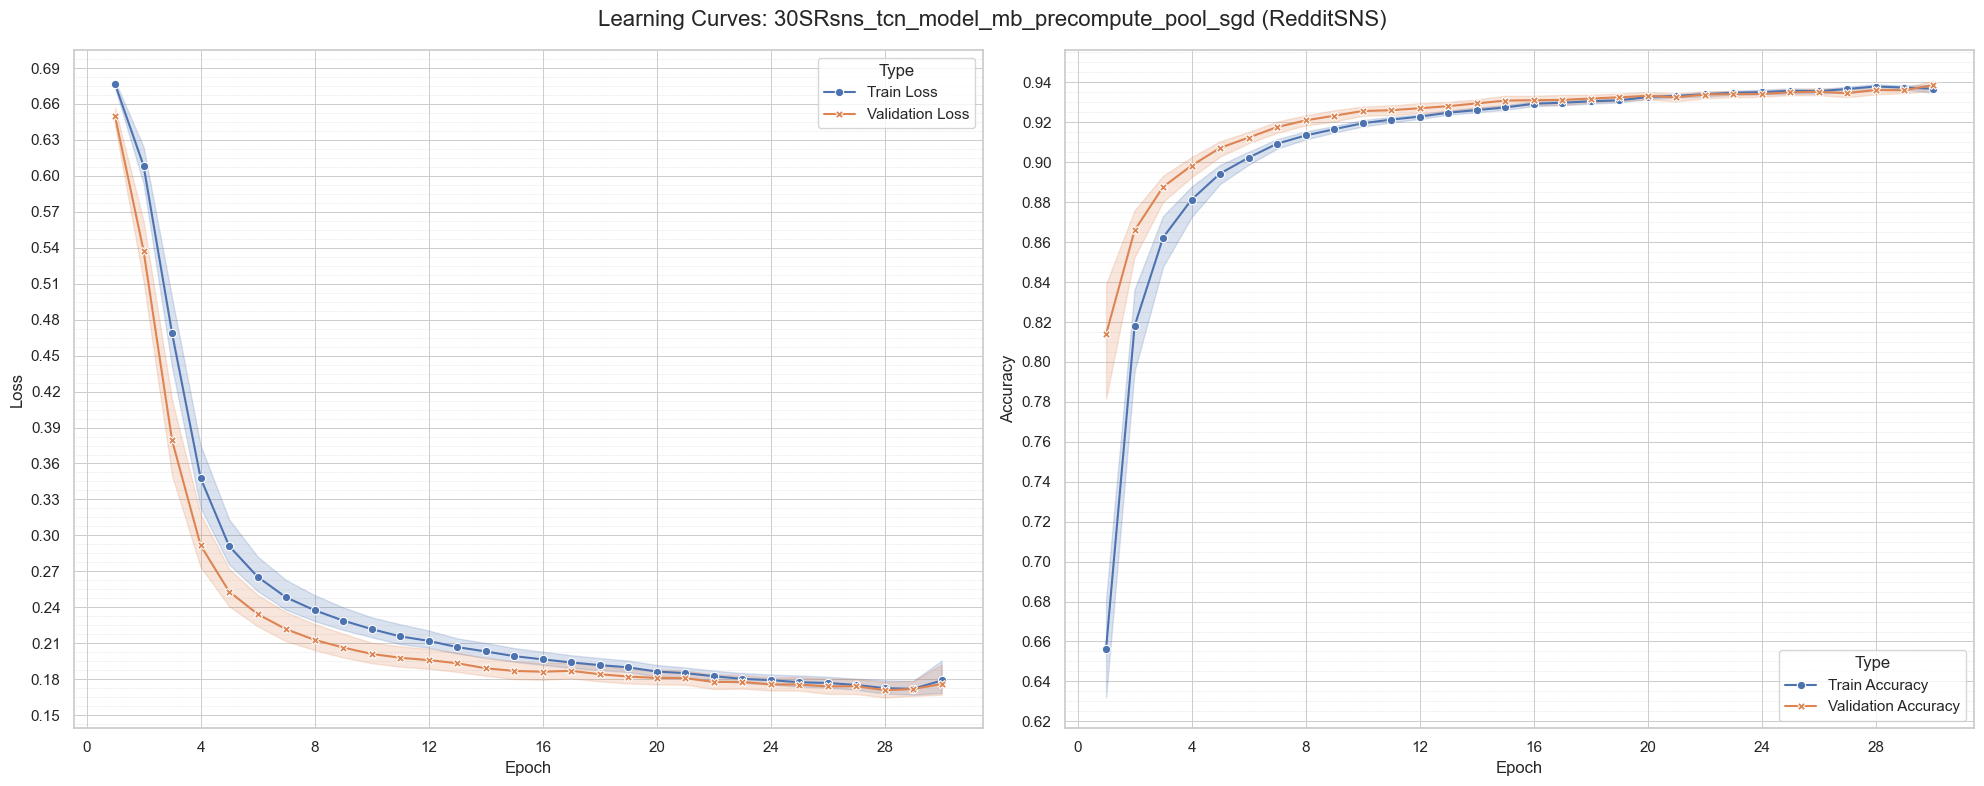

All plots generated.


In [3]:
import matplotlib.ticker as ticker

# Plotting Loop
for model in models:
    print(f"Processing {model['folder']}...")
    df_history = process_model_history(model)
    
    if df_history is None:
        print(f"Skipping {model['folder']} (No data)")
        continue
        
    # Count number of unique runs (folds/sheets)
    num_folds = df_history['Fold_Sheet'].nunique()
    print(f"  - Found {num_folds} runs/folds.")
    
    has_accuracy = 'accuracy' in df_history.columns and 'val_accuracy' in df_history.columns

    # Create figure
    if has_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(20, 8))
        ax_loss = axes[0]
        ax_acc = axes[1]
    else:
        fig, ax_loss = plt.subplots(1, 1, figsize=(10, 8))
        axes = [ax_loss] # For consistency if needed
        ax_acc = None

    # --- Plot 1: Loss ---
    # Melt for Loss
    df_loss = df_history.melt(id_vars=['Epoch', 'Fold_Sheet'], 
                              value_vars=['loss', 'val_loss'], 
                              var_name='Type', 
                              value_name='Loss')
    df_loss['Type'] = df_loss['Type'].replace({'loss': 'Train Loss', 'val_loss': 'Validation Loss'})
    
    sns.lineplot(data=df_loss, x='Epoch', y='Loss', hue='Type', style='Type', 
                 markers=True, dashes=False, errorbar=('ci', 95), ax=ax_loss)
    

    # Higher precision ticks
    ax_loss.yaxis.set_major_locator(ticker.MaxNLocator(nbins=20))
    ax_loss.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax_loss.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Ensure integer epochs
    ax_loss.grid(True, which='major', linestyle='-', linewidth=0.7)
    ax_loss.grid(True, which='minor', linestyle=':', linewidth=0.4)

    # --- Plot 2: Accuracy ---
    if has_accuracy:
        # Melt for Accuracy
        df_acc = df_history.melt(id_vars=['Epoch', 'Fold_Sheet'], 
                                  value_vars=['accuracy', 'val_accuracy'], 
                                  var_name='Type', 
                                  value_name='Accuracy')
        df_acc['Type'] = df_acc['Type'].replace({'accuracy': 'Train Accuracy', 'val_accuracy': 'Validation Accuracy'})
        
        sns.lineplot(data=df_acc, x='Epoch', y='Accuracy', hue='Type', style='Type', 
                     markers=True, dashes=False, errorbar=('ci', 95), ax=ax_acc)

        # Higher precision ticks
        ax_acc.yaxis.set_major_locator(ticker.MaxNLocator(nbins=20))
        ax_acc.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax_acc.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax_acc.grid(True, which='major', linestyle='-', linewidth=0.7)
        ax_acc.grid(True, which='minor', linestyle=':', linewidth=0.4)

    plt.suptitle(f"Learning Curves: {model['folder']} ({model['dataset']})", fontsize=16)
    plt.tight_layout()
    
    # Save plot to the model's folder
    model_dir = os.path.dirname(model['path'])
    save_path = os.path.join(model_dir, f"{model['folder']}_learning_curves_detailed.png")
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Saved to {save_path}")
    
    # Show plot in notebook
    plt.show()

print("All plots generated.")

# Summary
Plots have been generated and saved to the respective model folders.

The plots show:
1. **Training vs Validation Loss**
2. **Training vs Validation Accuracy**

**Key Features:**
- **Final Epoch Gap**: The gap between Training and Validation metrics at the final epoch is calculated and displayed on the graph.
    - Loss Gap = Val Loss - Train Loss
    - Accuracy Gap = Train Accuracy - Val Accuracy
- **Detailed Scalar**: The axes have higher precision ticks and grid lines for better readability.

- For **Baseline** models, the full 30 epochs are shown.
- For **other** models (with Early Stopping), the curves are truncated at the epoch with the minimum validation loss (best weights restored)
- The shaded area represents the confidence interval (95%).

In [4]:
import scipy.stats as stats
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Function to gather all results from _all_folds.xlsx files
def gather_all_results(base_paths, datasets):
    all_data = []
    
    for base_path in base_paths:
        for dataset in datasets:
            dataset_path = os.path.join(base_path, dataset)
            if not os.path.exists(dataset_path):
                continue
                
            for folder in os.listdir(dataset_path):
                if folder.startswith('30S') and os.path.isdir(os.path.join(dataset_path, folder)):
                    # Look for _all_folds.xlsx
                    # The filename usually follows the pattern: {folder}_all_folds.xlsx
                    # But sometimes it might be slightly different, so let's try to construct it
                    # based on the folder name, or look for any file ending in _all_folds.xlsx
                    
                    target_file = os.path.join(dataset_path, folder, f"{folder}_all_folds.xlsx")
                    
                    if not os.path.exists(target_file):
                        # Try searching for any *all_folds.xlsx file in the folder
                        files = [f for f in os.listdir(os.path.join(dataset_path, folder)) if f.endswith('_all_folds.xlsx')]
                        if files:
                            target_file = os.path.join(dataset_path, folder, files[0])
                        else:
                            continue
                            
                    try:
                        # Read the excel file
                        # We assume it might have multiple sheets (one per seed) or one sheet with all data
                        # The previous inspection showed 'Seed' as a column, so likely one sheet or concatenated sheets.
                        # Let's read all sheets and concatenate just in case.
                        xl = pd.ExcelFile(target_file, engine='openpyxl')
                        for sheet_name in xl.sheet_names:
                            df = pd.read_excel(target_file, sheet_name=sheet_name, engine='openpyxl')
                            
                            # Ensure we have the necessary columns
                            # We need 'Seed', 'Variant' (Model Name), 'Dataset', and metrics
                            if 'Variant' in df.columns:
                                df = df.rename(columns={'Variant': 'Model Name'})
                            
                            # If Dataset is missing, add it
                            if 'Dataset' not in df.columns:
                                df['Dataset'] = dataset
                                
                            all_data.append(df)
                            
                    except Exception as e:
                        print(f"Error reading {target_file}: {e}")
                        
    if not all_data:
        return pd.DataFrame()
        
    full_df = pd.concat(all_data, ignore_index=True)
    return full_df

# Define paths (reusing base_path from previous cells if available, else defining it)
if 'base_path' not in locals():
    base_path = [r'c:\Files\Degree\FYP\FYP_ver5\Results\30seeds_results']
if 'datasets' not in locals():
    datasets = ['Twitter','Twitter2','Reddit','RedditSNS']

print("Gathering data...")
full_df_v2 = gather_all_results(base_path, datasets)
print(f"Data gathered. Shape: {full_df_v2.shape}")
if not full_df_v2.empty:
    print("Models found:", full_df_v2['Model Name'].unique())
    print("Datasets found:", full_df_v2['Dataset'].unique())


Gathering data...
Data gathered. Shape: (240, 18)
Models found: ['baseline_algo' 'tcn_model_mb_precompute_pool_sgd']
Datasets found: ['Twitter' 'Twitter II' 'Reddit' 'Reddit SNS']


In [5]:
def perform_statistical_analysis(df, dataset_name, metric, baseline_model):
    print(f"\n{'='*20}\nStatistical Analysis: {dataset_name} - {metric}\n{'='*20}")
    
    # Filter data
    data = df[df['Dataset'] == dataset_name].copy()
    if data.empty:
        print(f"No data for {dataset_name}")
        return

    # Ensure Seed is string for consistent merging
    if 'Seed' in data.columns:
        data['Seed'] = data['Seed'].astype(str)
    else:
        print("Error: 'Seed' column not found.")
        return

    # Pivot data to get models side-by-side for each seed
    # We assume one row per seed per model.
    # If there are duplicates (e.g. multiple folds per seed), this pivot will fail or we need to aggregate.
    # The user specified "no need avg across fold as no cv and only one run each seed".
    # So we assume uniqueness.
    try:
        pivot_df = data.pivot(index='Seed', columns='Model Name', values=metric)
    except ValueError as e:
        print(f"Error pivoting data (check for duplicate seeds): {e}")
        return

    if baseline_model not in pivot_df.columns:
        print(f"Baseline model '{baseline_model}' not found in data.")
        print(f"Available models: {pivot_df.columns.tolist()}")
        return
    
    baseline_vals = pivot_df[baseline_model]
    other_models = [c for c in pivot_df.columns if c != baseline_model]
    alpha = 0.05
    
    # Determine if higher is better
    # Usually Accuracy, Precision, Recall, F1 are "higher is better"
    # Loss, Time, Memory are "lower is better"
    higher_is_better = True
    if any(x in metric.lower() for x in ['loss', 'time', 'memory', 'epochs']):
        higher_is_better = False
        
    alt_hyp_one_sided = 'greater' if higher_is_better else 'less'
    
    for model in other_models:
        model_vals = pivot_df[model]
        
        # Ensure we have paired data (same seeds)
        pair_df = pd.concat([baseline_vals, model_vals], axis=1).dropna()
        
        if len(pair_df) < 2:
            print(f"Not enough data points for comparison: {baseline_model} vs {model}")
            continue
            
        diff = pair_df[model] - pair_df[baseline_model]
        n = len(diff)
        mean_diff = diff.mean()
        std_diff = diff.std(ddof=1)
        
        print(f"\nComparison: {baseline_model} vs {model}")
        print(f"Number of Seeds: {n}")
        print(f"Mean Difference: {mean_diff:.4f}")
        
        # Confidence Interval (95%)
        if std_diff != 0:
            se = std_diff / np.sqrt(n)
            ci = stats.t.interval(1 - alpha, df=n-1, loc=mean_diff, scale=se)
            print(f"95% Confidence Interval: ({ci[0]:.4f}, {ci[1]:.4f})")
        else:
            print("95% Confidence Interval: (0.0000, 0.0000) [Zero Variance]")
        
        # Cohen's d
        cohens_d = mean_diff / std_diff if std_diff != 0 else 0
        print(f"Cohen's d: {cohens_d:.4f}")
        
        # --- One-Sided Tests ---
        print(f"--- One-Sided Tests (Alt: {alt_hyp_one_sided}) ---")
        
        # Paired T-Test
        t_stat, p_val_t = stats.ttest_rel(pair_df[model], pair_df[baseline_model], alternative=alt_hyp_one_sided)
        print(f"Paired T-Test: t={t_stat:.4f}, p={p_val_t:.4f}")
        print(f"  -> {'Reject H0 (Significant)' if p_val_t < alpha else 'Fail to reject H0'}")
        
        # Wilcoxon
        try:
            w_stat, p_val_w = stats.wilcoxon(pair_df[model], pair_df[baseline_model], alternative=alt_hyp_one_sided)
            print(f"Wilcoxon: stat={w_stat:.4f}, p={p_val_w:.4f}")
            print(f"  -> {'Reject H0 (Significant)' if p_val_w < alpha else 'Fail to reject H0'}")
        except Exception as e:
            print(f"Wilcoxon Failed: {e}")

        # --- Two-Sided Tests ---
        print(f"--- Two-Sided Tests (Alt: two-sided) ---")

        # Paired T-Test
        t_stat_2, p_val_t_2 = stats.ttest_rel(pair_df[model], pair_df[baseline_model], alternative='two-sided')
        print(f"Paired T-Test: t={t_stat_2:.4f}, p={p_val_t_2:.4f}")
        print(f"  -> {'Reject H0 (Significant)' if p_val_t_2 < alpha else 'Fail to reject H0'}")

        # Wilcoxon
        try:
            w_stat_2, p_val_w_2 = stats.wilcoxon(pair_df[model], pair_df[baseline_model], alternative='two-sided')
            print(f"Wilcoxon: stat={w_stat_2:.4f}, p={p_val_w_2:.4f}")
            print(f"  -> {'Reject H0 (Significant)' if p_val_w_2 < alpha else 'Fail to reject H0'}")
        except Exception as e:
            print(f"Wilcoxon Failed: {e}")

# Run Analysis
metrics_to_analyze = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
# Attempt to identify baseline name automatically or use default
baseline_name = 'baseline_algo' 
# Check if 'baseline_algo' exists in the gathered data
if not full_df_v2.empty:
    models = full_df_v2['Model Name'].unique()
    if baseline_name not in models:
        # Try to find a model name containing 'baseline'
        potential_baselines = [m for m in models if 'baseline' in m.lower()]
        if potential_baselines:
            baseline_name = potential_baselines[0]
            print(f"Using detected baseline: {baseline_name}")
        else:
            print(f"Warning: Default baseline '{baseline_name}' not found. Please update 'baseline_name'.")

if 'datasets' not in locals():
    datasets = full_df_v2['Dataset'].unique()

datasets = ['Twitter','Twitter II','Reddit','Reddit SNS']
for metric in metrics_to_analyze:
    for dataset in datasets:
        perform_statistical_analysis(full_df_v2, dataset, metric, baseline_name)


Statistical Analysis: Twitter - Accuracy

Comparison: baseline_algo vs tcn_model_mb_precompute_pool_sgd
Number of Seeds: 30
Mean Difference: -0.0040
95% Confidence Interval: (-0.0116, 0.0036)
Cohen's d: -0.1976
--- One-Sided Tests (Alt: greater) ---
Paired T-Test: t=-1.0824, p=0.8560
  -> Fail to reject H0
Wilcoxon: stat=93.5000, p=0.9979
  -> Fail to reject H0
--- Two-Sided Tests (Alt: two-sided) ---
Paired T-Test: t=-1.0824, p=0.2880
  -> Fail to reject H0
Wilcoxon: stat=93.5000, p=0.0042
  -> Reject H0 (Significant)

Statistical Analysis: Twitter II - Accuracy

Comparison: baseline_algo vs tcn_model_mb_precompute_pool_sgd
Number of Seeds: 30
Mean Difference: -0.0997
95% Confidence Interval: (-0.1046, -0.0948)
Cohen's d: -7.6413
--- One-Sided Tests (Alt: greater) ---
Paired T-Test: t=-41.8529, p=1.0000
  -> Fail to reject H0
Wilcoxon: stat=0.0000, p=1.0000
  -> Fail to reject H0
--- Two-Sided Tests (Alt: two-sided) ---
Paired T-Test: t=-41.8529, p=0.0000
  -> Reject H0 (Significant)